In [1]:
import pandas as pd
import numpy as np
import torch


df_train = pd.read_csv('../data/train_keystroke.csv')
df_test = pd.read_csv('../data/test_keystroke.csv')

def gerar_pares_siameses_robustos(df, aplicar_ruido=False):
    pares_features = []
    pares_labels = []

    agrupado = df.groupby('subject')
    lista_utilizadores = list(agrupado.groups.keys())

    for utilizador, grupo in agrupado:
        features = grupo.drop('subject', axis=1).values
        n_amostras = len(features)

        for i in range(n_amostras):
            idx_positivo = np.random.choice(n_amostras)
            amostra_ancora = features[i]
            amostra_positiva = features[idx_positivo]

            if aplicar_ruido and np.random.rand() > 0.5:
                ruido = np.random.normal(loc=0.0, scale=0.05, size=amostra_positiva.shape)
                amostra_positiva = amostra_positiva + ruido

            pares_features.append([amostra_ancora, amostra_positiva])
            pares_labels.append(1)

            utilizador_negativo = np.random.choice([u for u in lista_utilizadores if u != utilizador])
            grupo_negativo = agrupado.get_group(utilizador_negativo).drop('subject', axis=1).values
            idx_negativo = np.random.choice(len(grupo_negativo))

            pares_features.append([amostra_ancora, grupo_negativo[idx_negativo]])
            pares_labels.append(0)

    return np.array(pares_features), np.array(pares_labels)

print("=== FASE 1: GERAÇÃO DE PARES BIOMÉTRICOS ===")
print("Gerando pares de Treino com Data Augmentation 1D...")
X_train_pairs, y_train_labels = gerar_pares_siameses_robustos(df_train, aplicar_ruido=True)

print("Gerando pares de Teste completamente cegos (Mundo Real)...")
X_test_pairs, y_test_labels = gerar_pares_siameses_robustos(df_test, aplicar_ruido=False)

tensor_X_train = torch.tensor(X_train_pairs, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train_labels, dtype=torch.float32)

tensor_X_test = torch.tensor(X_test_pairs, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test_labels, dtype=torch.float32)

print("\n=== FASE 2: DIMENSÕES MATRICIAIS DOS TENSORES ===")
print(f"Formato X_train: {tensor_X_train.shape} (Pares, Elementos do Par, Número de Features)")
print(f"Formato y_train: {tensor_y_train.shape}")
print(f"Formato X_test: {tensor_X_test.shape}")

/tmp/ipykernel_25260/1092541657.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


=== FASE 1: GERAÇÃO DE PARES BIOMÉTRICOS ===
Gerando pares de Treino com Data Augmentation 1D...
Gerando pares de Teste completamente cegos (Mundo Real)...

=== FASE 2: DIMENSÕES MATRICIAIS DOS TENSORES ===
Formato X_train: torch.Size([23372, 2, 21]) (Pares, Elementos do Par, Número de Features)
Formato y_train: torch.Size([23372])
Formato X_test: torch.Size([8324, 2, 21])



=== FASE 2.5: VALIDAÇÃO VISUAL DO PRE-PROCESSAMENTO ===


/tmp/ipykernel_25260/2679421648.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Fraudes (0)', 'Autênticos (1)'], y=contagens, palette=['coral', 'teal'], ax=axes[0])


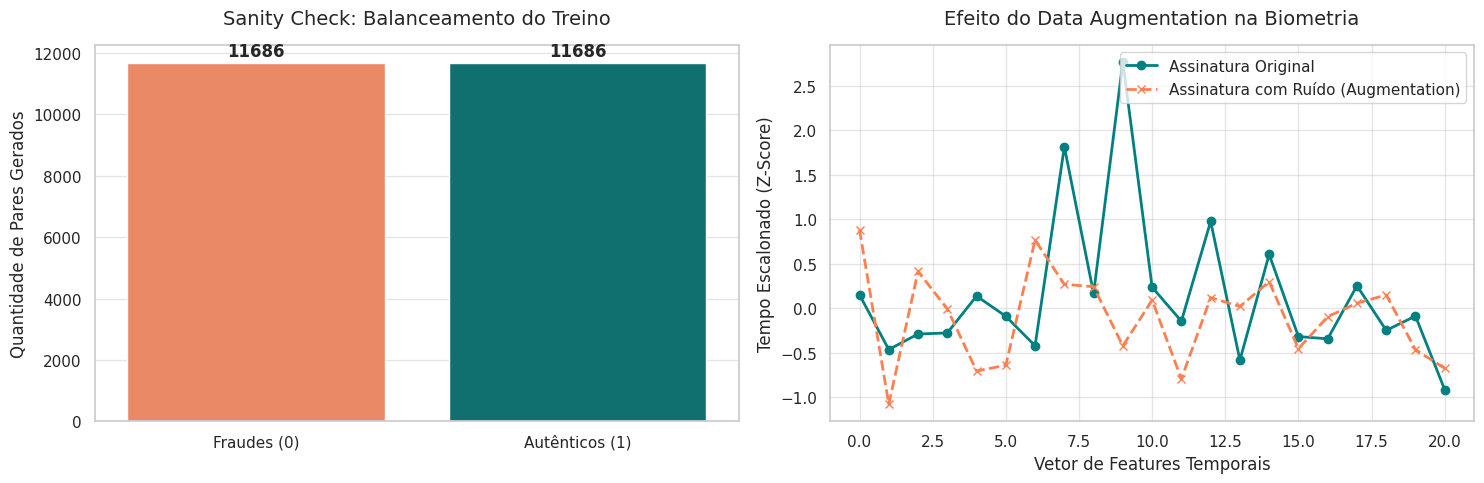

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== FASE 2.5: VALIDAÇÃO VISUAL DO PRE-PROCESSAMENTO ===")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

labels_treino = tensor_y_train.numpy()
unicos, contagens = np.unique(labels_treino, return_counts=True)

sns.barplot(x=['Fraudes (0)', 'Autênticos (1)'], y=contagens, palette=['coral', 'teal'], ax=axes[0])
axes[0].set_title("Sanity Check: Balanceamento do Treino", fontsize=14, pad=15)
axes[0].set_ylabel("Quantidade de Pares Gerados", fontsize=12)

for i, v in enumerate(contagens):
    axes[0].text(i, v + (max(contagens)*0.02), str(v), ha='center', fontsize=12, fontweight='bold')


indice_exemplo = np.where(labels_treino == 1)[0][0]
assinatura_ancora = tensor_X_train[indice_exemplo, 0, :].numpy()
assinatura_ruido = tensor_X_train[indice_exemplo, 1, :].numpy()

eixo_x = np.arange(len(assinatura_ancora))

axes[1].plot(eixo_x, assinatura_ancora, label='Assinatura Original', color='teal', linewidth=2, marker='o')
axes[1].plot(eixo_x, assinatura_ruido, label='Assinatura com Ruído (Augmentation)', color='coral', linewidth=2, linestyle='--', marker='x')

axes[1].set_title("Efeito do Data Augmentation na Biometria", fontsize=14, pad=15)
axes[1].set_xlabel("Vetor de Features Temporais", fontsize=12)
axes[1].set_ylabel("Tempo Escalonado (Z-Score)", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()


In [3]:
from torch.utils.data import TensorDataset, DataLoader
import os

train_dataset = TensorDataset(tensor_X_train, tensor_y_train)
test_dataset = TensorDataset(tensor_X_test, tensor_y_test)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("=== FASE 3: CONFIGURAÇÃO DOS DATALOADERS ===")
print(f"Tamanho do lote definido: {BATCH_SIZE} amostras por iteração")
print(f"Total de lotes de Treino (Pulsos por Época): {len(train_loader)}")
print(f"Total de lotes de Teste: {len(test_loader)}")


os.makedirs('../data', exist_ok=True)

torch.save(tensor_X_train, '../data/tensor_X_train.pt')
torch.save(tensor_y_train, '../data/tensor_y_train.pt')
torch.save(tensor_X_test, '../data/tensor_X_test.pt')
torch.save(tensor_y_test, '../data/tensor_y_test.pt')

print("\n=== FASE 4: EXPORTAÇÃO COMPLETA ===")
print("Tensores guardados como ficheiros binários '.pt' na pasta 'data/'.")

=== FASE 3: CONFIGURAÇÃO DOS DATALOADERS ===
Tamanho do lote definido: 128 amostras por iteração
Total de lotes de Treino (Pulsos por Época): 183
Total de lotes de Teste: 66

=== FASE 4: EXPORTAÇÃO COMPLETA ===
Tensores guardados como ficheiros binários '.pt' na pasta 'data/'.
